In [1]:
import requests
import os
from pathlib import Path

# Create a folder to store the data
data_dir = Path("data/taxi")
data_dir.mkdir(parents=True, exist_ok=True)

base_url = "https://d37ci6vzurychx.cloudfront.net/trip-data"
months = [f"{m:02d}" for m in range(1, 13)]  # 01 to 12

total = len(months)
for i, month in enumerate(months, 1):
    filename = f"yellow_tripdata_2023-{month}.parquet"
    filepath = data_dir / filename
    url = f"{base_url}/{filename}"

    # Skip if already downloaded
    if filepath.exists():
        print(f"[{i}/{total}] Already exists, skipping: {filename}")
        continue

    print(f"[{i}/{total}] Downloading {filename}...")
    response = requests.get(url, stream=True)

    if response.status_code == 200:
        total_size = int(response.headers.get("content-length", 0))
        downloaded = 0
        with open(filepath, "wb") as f:
            for chunk in response.iter_content(chunk_size=1024*1024):  # 1MB chunks
                f.write(chunk)
                downloaded += len(chunk)
                mb_done = downloaded / (1024*1024)
                mb_total = total_size / (1024*1024)
                print(f"  {mb_done:.1f} MB / {mb_total:.1f} MB", end="\r")
        print(f"  ✅ Done! ({mb_total:.1f} MB)")
    else:
        print(f"  ❌ Failed to download {filename} (status {response.status_code})")

print("\n🎉 All done! Files saved in data/taxi/")

[1/12] Downloading yellow_tripdata_2023-01.parquet...
  ✅ Done! (45.5 MB)
[2/12] Downloading yellow_tripdata_2023-02.parquet...
  ✅ Done! (45.5 MB)
[3/12] Downloading yellow_tripdata_2023-03.parquet...
  ✅ Done! (53.5 MB)
[4/12] Downloading yellow_tripdata_2023-04.parquet...
  ✅ Done! (51.7 MB)
[5/12] Downloading yellow_tripdata_2023-05.parquet...
  ✅ Done! (55.9 MB)
[6/12] Downloading yellow_tripdata_2023-06.parquet...
  ✅ Done! (52.5 MB)
[7/12] Downloading yellow_tripdata_2023-07.parquet...
  ✅ Done! (46.1 MB)
[8/12] Downloading yellow_tripdata_2023-08.parquet...
  ✅ Done! (45.9 MB)
[9/12] Downloading yellow_tripdata_2023-09.parquet...
  ✅ Done! (45.7 MB)
[10/12] Downloading yellow_tripdata_2023-10.parquet...
  ✅ Done! (56.3 MB)
[11/12] Downloading yellow_tripdata_2023-11.parquet...
  ✅ Done! (53.5 MB)
[12/12] Downloading yellow_tripdata_2023-12.parquet...
  ✅ Done! (54.2 MB)

🎉 All done! Files saved in data/taxi/


In [2]:
import glob
import pandas as pd

files = sorted(glob.glob("data/taxi/yellow_tripdata_2023-*.parquet"))

dfs = []
for f in files:
    print(f"Loading {f}...")
    df_month = pd.read_parquet(f, columns=[
        "tpep_pickup_datetime",
        "tip_amount",
        "fare_amount",
        "trip_distance",
        "passenger_count",
        "payment_type"
    ])
    dfs.append(df_month)

df_full = pd.concat(dfs, ignore_index=True)
print(f"\nTotal rows: {len(df_full):,}")
print(f"Date range: {df_full['tpep_pickup_datetime'].min()} → {df_full['tpep_pickup_datetime'].max()}")
print(f"Memory usage: {df_full.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(df_full.dtypes)

Loading data/taxi/yellow_tripdata_2023-01.parquet...
Loading data/taxi/yellow_tripdata_2023-02.parquet...
Loading data/taxi/yellow_tripdata_2023-03.parquet...
Loading data/taxi/yellow_tripdata_2023-04.parquet...
Loading data/taxi/yellow_tripdata_2023-05.parquet...
Loading data/taxi/yellow_tripdata_2023-06.parquet...
Loading data/taxi/yellow_tripdata_2023-07.parquet...
Loading data/taxi/yellow_tripdata_2023-08.parquet...
Loading data/taxi/yellow_tripdata_2023-09.parquet...
Loading data/taxi/yellow_tripdata_2023-10.parquet...
Loading data/taxi/yellow_tripdata_2023-11.parquet...
Loading data/taxi/yellow_tripdata_2023-12.parquet...

Total rows: 38,310,226
Date range: 2001-01-01 00:06:49 → 2024-01-03 19:42:57
Memory usage: 1753.7 MB
tpep_pickup_datetime    datetime64[us]
tip_amount                     float64
fare_amount                    float64
trip_distance                  float64
passenger_count                float64
payment_type                     int64
dtype: object


In [3]:
# Check how many rows have dates outside 2023
bad_dates = df_full[
    (df_full["tpep_pickup_datetime"] < "2023-01-01") |
    (df_full["tpep_pickup_datetime"] >= "2024-01-01")
]
print(f"Total rows: {len(df_full):,}")
print(f"Rows with bad dates: {len(bad_dates):,}")
print(f"Percentage: {len(bad_dates)/len(df_full)*100:.4f}%")
print(f"\nBad date examples:")
print(bad_dates["tpep_pickup_datetime"].sort_values().head(10))
print(bad_dates["tpep_pickup_datetime"].sort_values().tail(10))

Total rows: 38,310,226
Rows with bad dates: 104
Percentage: 0.0003%

Bad date examples:
7242962    2001-01-01 00:06:49
12418145   2001-01-01 00:07:36
12317376   2001-01-01 00:08:31
9107849    2001-01-01 00:08:42
12424527   2001-01-01 00:28:40
7472619    2001-01-01 15:18:51
36062418   2002-12-31 22:16:54
20854616   2002-12-31 22:27:05
37464864   2002-12-31 23:03:18
16652692   2002-12-31 23:03:19
Name: tpep_pickup_datetime, dtype: datetime64[us]
1177       2022-12-31 23:59:25
567        2022-12-31 23:59:37
3864       2022-12-31 23:59:40
4153       2022-12-31 23:59:48
38129318   2024-01-01 00:01:34
38129418   2024-01-01 00:01:58
37742559   2024-01-03 10:00:04
37742560   2024-01-03 17:00:52
37742561   2024-01-03 18:43:26
37742562   2024-01-03 19:42:57
Name: tpep_pickup_datetime, dtype: datetime64[us]


In [4]:
# Filter to valid 2023 data only
df_full = df_full[
    (df_full["tpep_pickup_datetime"] >= "2023-01-01") &
    (df_full["tpep_pickup_datetime"] < "2024-01-01") &
    (df_full["payment_type"] == 1) &        # credit card only
    (df_full["fare_amount"] >= 2.50) &      # valid fares
    (df_full["trip_distance"] > 0) &        # valid trips
    (df_full["tip_amount"] > 0)             # has a tip
]

# Calculate tip percentage
df_full["tip_pct"] = (df_full["tip_amount"] / df_full["fare_amount"]) * 100
df_full = df_full[df_full["tip_pct"] <= 100]

# Extract time features
df_full["hour"] = df_full["tpep_pickup_datetime"].dt.hour
df_full["month"] = df_full["tpep_pickup_datetime"].dt.month
df_full["day_of_week"] = df_full["tpep_pickup_datetime"].dt.day_name()
df_full["is_late_night"] = df_full["hour"].between(22, 23) | df_full["hour"].between(0, 4)
df_full["date_hour"] = df_full["tpep_pickup_datetime"].dt.floor("h")

print(f"Rows after cleaning: {len(df_full):,}")
print(f"Date range: {df_full['tpep_pickup_datetime'].min()} → {df_full['tpep_pickup_datetime'].max()}")
print(f"\nTip % stats:\n{df_full['tip_pct'].describe().round(2)}")

Rows after cleaning: 28,239,159
Date range: 2023-01-01 00:00:09 → 2023-12-31 23:59:59

Tip % stats:
count    28239159.00
mean           25.87
std             9.38
min             0.00
25%            21.72
50%            26.17
75%            30.74
max           100.00
Name: tip_pct, dtype: float64


In [5]:
import requests

url_weather = "https://archive-api.open-meteo.com/v1/archive"

params_weather = {
    "latitude": 40.7831,
    "longitude": -73.9712,
    "start_date": "2023-01-01",
    "end_date": "2023-12-31",
    "hourly": "temperature_2m,precipitation,rain,snowfall,windspeed_10m,weathercode",
    "timezone": "America/New_York"
}

response_weather = requests.get(url_weather, params=params_weather)
data = response_weather.json()

weather_full = pd.DataFrame({
    "date_hour": pd.to_datetime(data["hourly"]["time"]),
    "temperature": data["hourly"]["temperature_2m"],
    "precipitation": data["hourly"]["precipitation"],
    "rain": data["hourly"]["rain"],
    "snowfall": data["hourly"]["snowfall"],
    "windspeed": data["hourly"]["windspeed_10m"],
    "weathercode": data["hourly"]["weathercode"],
})

print(f"Weather rows: {len(weather_full):,}")
print(f"Date range: {weather_full['date_hour'].min()} → {weather_full['date_hour'].max()}")
print(weather_full.head())

Weather rows: 8,760
Date range: 2023-01-01 00:00:00 → 2023-12-31 23:00:00
            date_hour  temperature  precipitation  rain  snowfall  windspeed  \
0 2023-01-01 00:00:00         10.9            1.1   1.1       0.0       11.7   
1 2023-01-01 01:00:00         10.9            0.9   0.9       0.0        9.1   
2 2023-01-01 02:00:00         10.8            0.1   0.1       0.0       14.4   
3 2023-01-01 03:00:00         10.8            0.0   0.0       0.0       16.6   
4 2023-01-01 04:00:00         10.1            0.0   0.0       0.0       16.9   

   weathercode  
0           55  
1           53  
2           51  
3            0  
4            0  


In [6]:
# Merge
merged_full = df_full.merge(weather_full, on="date_hour", how="left")

# Add weather flags
merged_full["bad_weather"] = (merged_full["precipitation"] > 0) | (merged_full["snowfall"] > 0)
merged_full["heavy_rain"] = merged_full["precipitation"] >= 2.0
merged_full["snowing"] = merged_full["snowfall"] > 0
merged_full["cold"] = merged_full["temperature"] < 0  # below freezing

print(f"Merged rows: {len(merged_full):,}")
print(f"Rides in bad weather: {merged_full['bad_weather'].sum():,} ({merged_full['bad_weather'].mean()*100:.1f}%)")
print(f"Rides in heavy rain: {merged_full['heavy_rain'].sum():,} ({merged_full['heavy_rain'].mean()*100:.1f}%)")
print(f"Rides in snow: {merged_full['snowing'].sum():,} ({merged_full['snowing'].mean()*100:.1f}%)")

Merged rows: 28,239,159
Rides in bad weather: 4,361,170 (15.4%)
Rides in heavy rain: 633,496 (2.2%)
Rides in snow: 246,181 (0.9%)


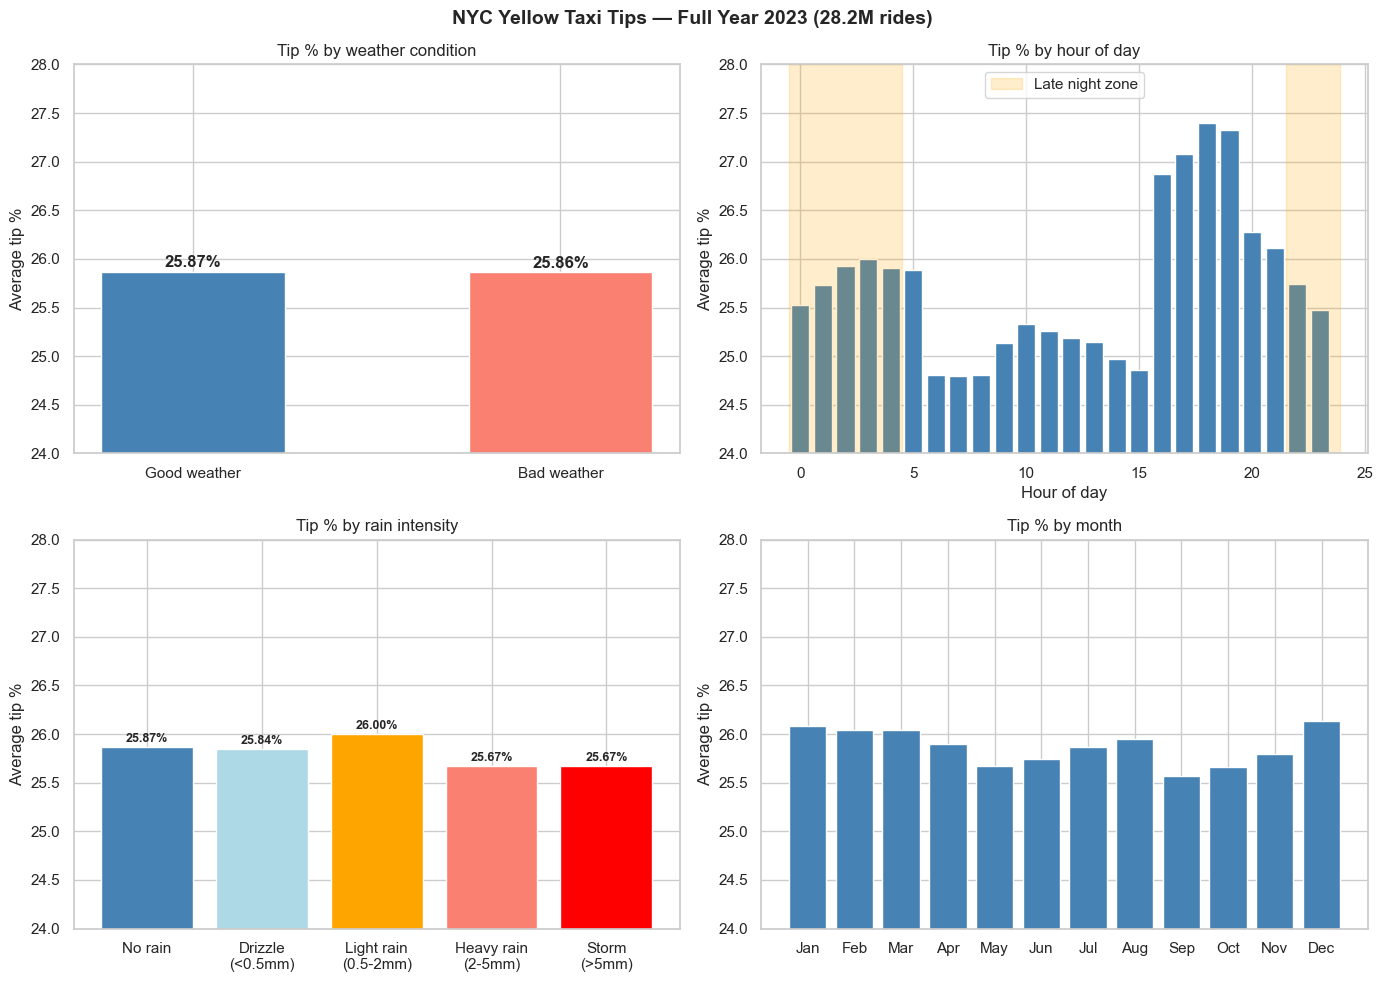


=== KEY FINDINGS ===
Good weather avg tip: 25.87%
Bad weather avg tip:  25.86%
Difference: -0.01%

Late night avg tip: 25.67%
Daytime avg tip:    25.91%


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Bad vs good weather
weather_means = merged_full.groupby("bad_weather")["tip_pct"].mean()
axes[0,0].bar(["Good weather", "Bad weather"], weather_means.values,
              color=["steelblue", "salmon"], width=0.5)
axes[0,0].set_ylabel("Average tip %")
axes[0,0].set_title("Tip % by weather condition")
axes[0,0].set_ylim(24, 28)
for i, v in enumerate(weather_means.values):
    axes[0,0].text(i, v + 0.05, f"{v:.2f}%", ha="center", fontweight="bold")

# Plot 2: Tip % by hour of day
hourly = merged_full.groupby("hour")["tip_pct"].mean()
axes[0,1].bar(hourly.index, hourly.values, color="steelblue")
axes[0,1].axvspan(21.5, 23.9, color="orange", alpha=0.2, label="Late night")
axes[0,1].axvspan(-0.5, 4.5, color="orange", alpha=0.2)
axes[0,1].set_xlabel("Hour of day")
axes[0,1].set_ylabel("Average tip %")
axes[0,1].set_title("Tip % by hour of day")
axes[0,1].set_ylim(24, 28)
axes[0,1].legend(["Late night zone"])

# Plot 3: Tip % by precipitation intensity
bins = [-0.01, 0, 0.5, 2.0, 5.0, 100]
labels = ["No rain", "Drizzle\n(<0.5mm)", "Light rain\n(0.5-2mm)", "Heavy rain\n(2-5mm)", "Storm\n(>5mm)"]
merged_full["rain_category"] = pd.cut(merged_full["precipitation"], bins=bins, labels=labels)
rain_means = merged_full.groupby("rain_category", observed=True)["tip_pct"].mean()
axes[1,0].bar(rain_means.index, rain_means.values,
              color=["steelblue", "lightblue", "orange", "salmon", "red"])
axes[1,0].set_ylabel("Average tip %")
axes[1,0].set_title("Tip % by rain intensity")
axes[1,0].set_ylim(24, 28)
for i, v in enumerate(rain_means.values):
    axes[1,0].text(i, v + 0.05, f"{v:.2f}%", ha="center", fontweight="bold", fontsize=9)

# Plot 4: Tip % by month
monthly = merged_full.groupby("month")["tip_pct"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[1,1].bar(month_names, monthly.values, color="steelblue")
axes[1,1].set_ylabel("Average tip %")
axes[1,1].set_title("Tip % by month")
axes[1,1].set_ylim(24, 28)

plt.suptitle("NYC Yellow Taxi Tips — Full Year 2023 (28.2M rides)", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/Users/manostsili/Desktop/tip_analysis_full_year.png", dpi=150)
plt.show()

# Print key numbers
print("\n=== KEY FINDINGS ===")
print(f"Good weather avg tip: {weather_means[False]:.2f}%")
print(f"Bad weather avg tip:  {weather_means[True]:.2f}%")
print(f"Difference: {weather_means[True] - weather_means[False]:.2f}%")
print(f"\nLate night avg tip: {merged_full[merged_full['is_late_night']]['tip_pct'].mean():.2f}%")
print(f"Daytime avg tip:    {merged_full[~merged_full['is_late_night']]['tip_pct'].mean():.2f}%")